<a href="https://colab.research.google.com/github/ViviCT8711/ViviCT8711.github.io/blob/main/Examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ESTADÍSTICA PARA CIENCIA DE DATOS**

# **1. Resumen del análisis**

En el presente examen se busca aplicar de forma crítica y estructurada los conceptos fundamentales y avanzados de la estadística bayesiana mediante el análisis de un conjunto de datos simulados. El propósito es integrar conocimientos teóricos con habilidades prácticas utilizando R, apoyándose en herramientas estadísticas descriptivas e inferenciales desde el enfoque bayesiano.
El análisis bayesiano que se realizó fue: regresión y clustering, empleando regresión Elastic Net y modelos de mezcla Bayesiana.

# **2. Introducción**

Dada que la estadística con enfoque Bayesiano incluye un conocimientro previo (priori) de los parametros, que son tratados como variables aleatorias, y la inferencia que se estima se basa en la distribución a posteriori, que se construye con el conocimiento de los parametros después de observar los datos. Por lo tanto en este caso resulta importante su uso asignando un valor de las probabilidad, inclusive a eventos no repetidos, en el que los parametros se modelen como variables aleatorios y no como cantidades fijas y determinista.

La regresión Elastic Net, combina Ridge y Lasso mediante penalización mixta, las variables necesarias son similares a las de Ridge, pero se asume que hay correlaciones entre variables y la necesidad de regularización para estabilizar y seleccionar variables relevantes, según el material de estudio es lo mejor de los 2 mundos

Por otro lado, se usa los modelos de mezcla Bayesiana considerando que según el material de estudio este es ideal para descubrir patrones y agrupaciones en los datos de manera probabilística, asignando probabilidades a la pertenencia a los grupos, además revisado en material expuesto que reafirma que Un modelo de mezclas bayesiano es una técnica estadística que se utiliza para modelar datos que provienen de diferentes fuentes o distribuciones, asumiendo que cada fuente sigue un modelo probabilístico específico. En esencia, busca agrupar datos en clusters, donde cada cluster representa una fuente o distribución diferente. Este enfoque permite estimar las características de cada fuente, así como la proporción de datos que pertenecen a cada una.

Ambos temas han sido abordados en la unidad 3 de la asignatura, mediante el uso de material propio de la docente, videos complementario y exposiciones grupales que muestran la aplicación de la estadística bayesiana en distintas áreas.

# **3. Metodología**

**Carga de librerias necesarias para la regresión**

In [ ]:
#EJERCICIO 1
# Cargar librerías principales ------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV

## **Descripción del dataset:**

In [ ]:
# Semilla para reproducibilidad
np.random.seed(42)
n_samples = 300

# Simulación de variables típicas de estudiantes universitarios
sexo = np.random.choice([0, 1], size=n_samples)  # 0=Femenino, 1=Masculino
edad = np.clip(np.random.normal(loc=21, scale=2.5, size=n_samples), 17, 30)
edad = np.round(edad).astype(int)  # Edad sin decimales
estado_laboral = np.random.choice([0, 1], n_samples)  # 0=No trabaja, 1=Trabaja
beca = np.random.choice([0, 1], n_samples) # 0=No tiene beca, 1=Tiene beca
horas_estudio_autonomo = np.random.normal(3, 1, n_samples)
horas_estudio_autonomo = np.round(horas_estudio_autonomo).astype(int)  # Horas de estudio sin decimales
acceso_internet = np.random.choice([0, 1], n_samples)  # 0=No tiene acceso a internet en el hogar, 1=Sí acceso a internet en el hogar
nivel_socioeconomico = np.random.choice([1, 2, 3], n_samples)  # Ordinal 1-bajo a 3-alto

# Variable dependiente: promedio simulado con efectos de las variables
promedio = (
    0.3 * edad +
    0.5 * horas_estudio_autonomo +
    1.2 * sexo -
    0.8 * estado_laboral +
    1.5 * beca +
    0.9 * acceso_internet +
    0.7 * nivel_socioeconomico +
    np.random.normal(0, 2, n_samples)
)
promedio = np.clip(promedio, 0, 10)  # Restringir valores entre 0 y 10
promedio = np.round(promedio, 2)    # Promedio con 2 decimales

# Construcción del DataFrame
datos_estudiantiles = pd.DataFrame({
    "Sexo": sexo,
    "Edad": edad,
    "Estado_laboral": estado_laboral,
    "Beca": beca,
    "Horas_estudio_autonomo": horas_estudio_autonomo,
    "Acceso_internet": acceso_internet,
    "Nivel_socioeconomico": nivel_socioeconomico,
    "Promedio": promedio
})

# Vista previa
print(datos_estudiantiles.head())

   Sexo  Edad  Estado_laboral  Beca  Horas_estudio_autonomo  Acceso_internet  \
0     0    21               1     1                       6                0   
1     1    22               0     1                       3                1   
2     0    21               1     0                       3                1   
3     0    18               1     1                       3                0   
4     0    24               1     0                       3                1   

   Nivel_socioeconomico  Promedio  
0                     1     10.00  
1                     3     10.00  
2                     3     10.00  
3                     3      8.16  
4                     3      8.03  


Como se puede observar el conjunto de datos personales, económicos y académicos de estudiantes universitarios son simulados, variables tales como: edad, sexo, horas de estudio, promedio general, situación laboral, nivel socioeconómico y acceso a internet.

## **Estructura del conjunto de datos**

In [ ]:
datos_estudiantiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sexo                    300 non-null    int64  
 1   Edad                    300 non-null    int64  
 2   Estado_laboral          300 non-null    int64  
 3   Beca                    300 non-null    int64  
 4   Horas_estudio_autonomo  300 non-null    int64  
 5   Acceso_internet         300 non-null    int64  
 6   Nivel_socioeconomico    300 non-null    int64  
 7   Promedio                300 non-null    float64
dtypes: float64(1), int64(7)
memory usage: 18.9 KB


## **Análisis descriptivo**

*Variables cuantitativas*

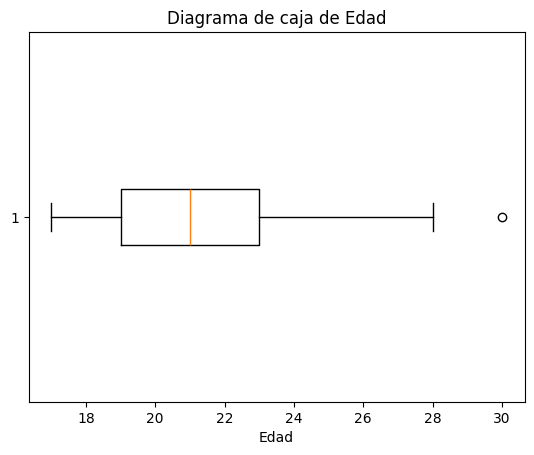

In [ ]:
# Edad (diagrama de caja)
plt.boxplot(datos_estudiantiles["Edad"], vert=False)
plt.title("Diagrama de caja de Edad")
plt.xlabel("Edad")
plt.show()


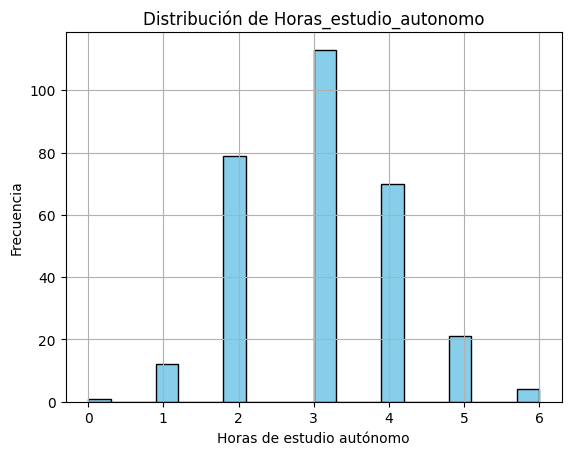

In [ ]:
# Horas_estudio_autonomo (histograma)
plt.hist(datos_estudiantiles["Horas_estudio_autonomo"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribución de Horas_estudio_autonomo")
plt.xlabel("Horas de estudio autónomo")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

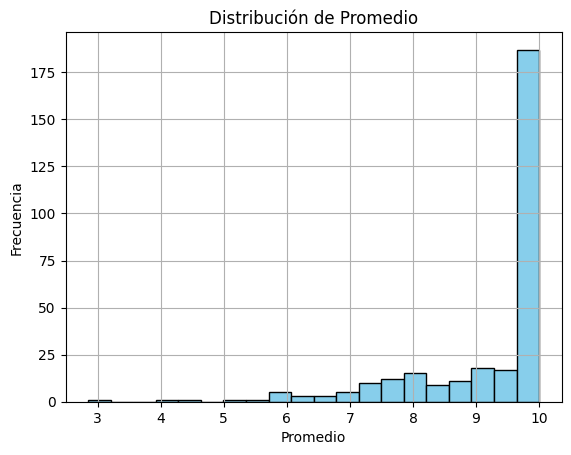

In [ ]:
# Promedio (histograma)
plt.hist(datos_estudiantiles["Promedio"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribución de Promedio")
plt.xlabel("Promedio")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

*Variables binarias y ordinales*

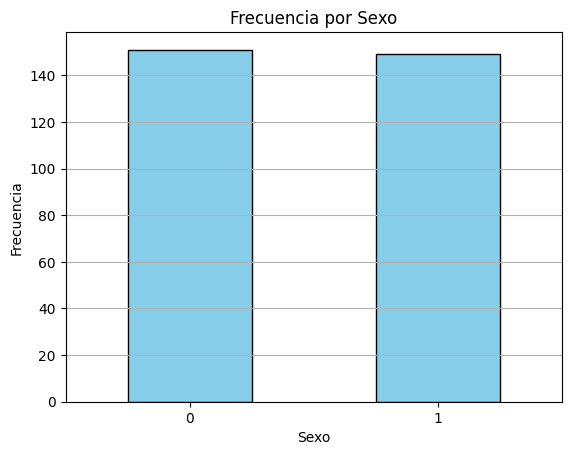

In [ ]:
# Sexo (gráfico de barras)
counts = datos_estudiantiles["Sexo"].value_counts().sort_index()
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frecuencia por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

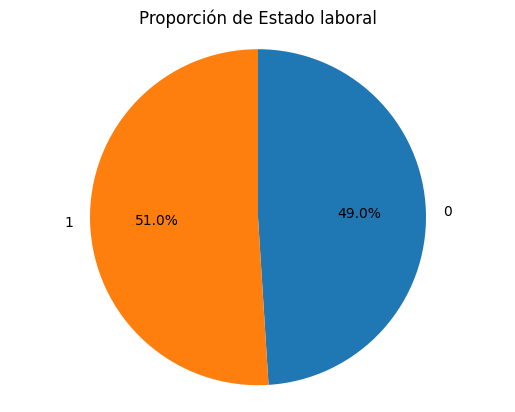

In [ ]:
# Estado_laboral (gráfico circular)
counts = datos_estudiantiles["Estado_laboral"].value_counts().sort_index()
counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Proporción de Estado laboral")
plt.ylabel("")
plt.axis('equal')
plt.show()

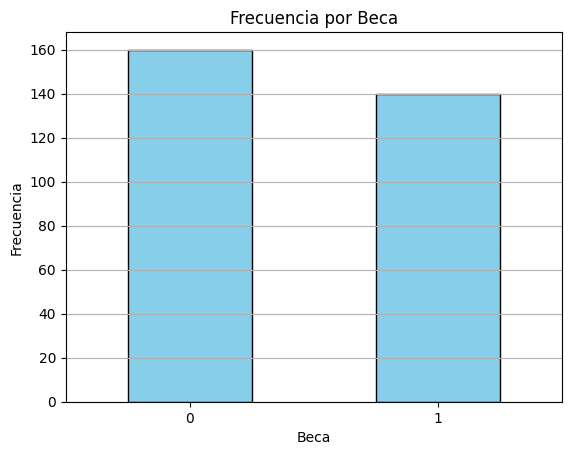

In [ ]:
# Beca (gráfico de barras)
counts = datos_estudiantiles["Beca"].value_counts().sort_index()
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frecuencia por Beca")
plt.xlabel("Beca")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

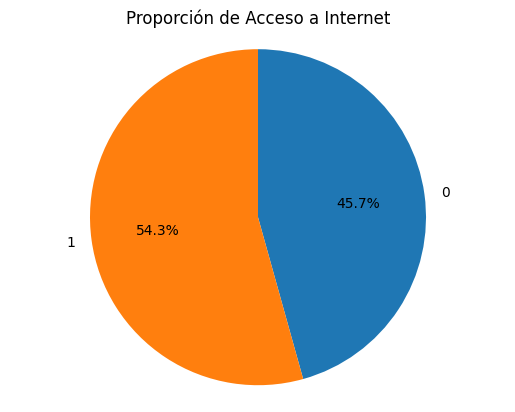

In [ ]:
#Acceso_internet (gráfico circular)
counts = datos_estudiantiles["Acceso_internet"].value_counts().sort_index()
counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Proporción de Acceso a Internet")
plt.ylabel("")
plt.axis('equal')
plt.show()

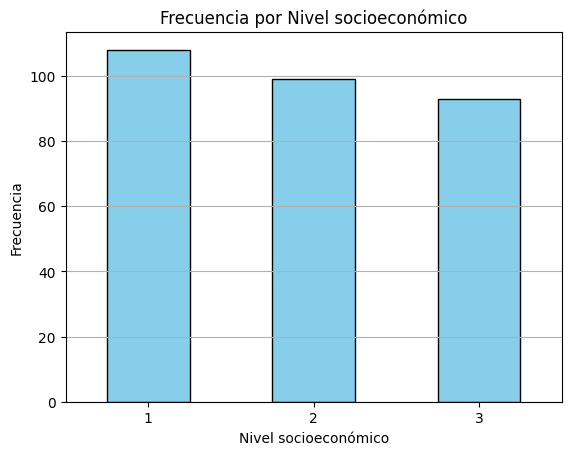

In [ ]:
# Nivel_socioeconomico (gráfico de barras)
counts = datos_estudiantiles["Nivel_socioeconomico"].value_counts().sort_index()
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frecuencia por Nivel socioeconómico")
plt.xlabel("Nivel socioeconómico")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Prueba de normalidad (Shapiro-Wilk) para variables cuantitativas

In [ ]:
from scipy.stats import shapiro
# Lista completa de variables cuantitativas del dataframe datos_estudiantiles
variables_cuantitativas = ['Edad', 'Horas_estudio_autonomo', 'Promedio']
normalidad_resultados = []

# Aplicar prueba de Shapiro-Wilk a cada variable cuantitativa
for var in variables_cuantitativas:
    stat, p = shapiro(datos_estudiantiles[var])
    normal = 'Sí' if p > 0.05 else 'No'
    normalidad_resultados.append({
        'Variable': var,
        'Estadístico W': round(stat, 4),
        'Valor p': round(p, 4),
        '¿Distribución Normal?': normal
    })

# Mostrar tabla de resultados
tabla_normalidad = pd.DataFrame(normalidad_resultados)
display(tabla_normalidad)


,Variable,Estadístico W,Valor p,¿Distribución Normal?
0,Edad,0.9693,0.0,No
1,Horas_estudio_autonomo,0.9177,0.0,No
2,Promedio,0.6791,0.0,No


Análisis de correlación

,Edad,Horas_estudio_autonomo,Promedio
Edad,1.000000,0.028756,0.194594
Horas_estudio_autonomo,0.028756,1.000000,0.217745
Promedio,0.194594,0.217745,1.000000


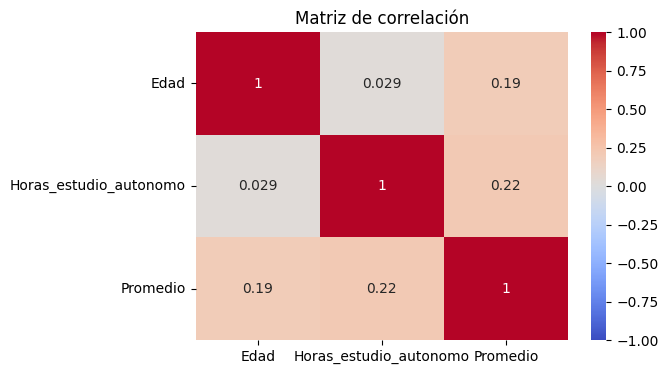

In [ ]:
# Variables numéricas para correlación en tu dataframe datos_estudiantiles
variables_corr = ['Edad', 'Horas_estudio_autonomo', 'Promedio']

# Calcular matriz de correlación
correlacion = datos_estudiantiles[variables_corr].corr()

# Mostrar matriz de correlación
display(correlacion)

# Opcional: mapa de calor para visualizar correlaciones
plt.figure(figsize=(6, 4))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()


En este análisis estadístico, se mostró visualmente todas las variables y sobre las variables cuantitativas se aplicó la prueba de normalidad de Shapiro-Wilk y esta indicó que todas las variables no siguen una distribución normal. La matriz de correlación mostró que no se encontraron asociaciones estadísticamente significativas entre ninguna de las combinaciones de variables, y los coeficientes obtenidos reflejan relaciones muy débiles o nulas.

## **Modelo bayesiano**

**Regresión Elastic Net**

Justificación del modelo.-

Descripción del enfoque .-

Implementación en Python con código comentado.-

Intercepto modelo e_net: 5.668474225444925
Coeficientes modelo e_net: [ 0.50808038  0.09703592 -0.39029807  0.37799465  0.24185253  0.22727751
  0.22418169]
Intercepto modelo e_net_b: 5.581218982792234
Coeficientes modelo e_net_b: [ 0.55812065  0.09792796 -0.42290793  0.41404125  0.24906099  0.25099222
  0.22848719]


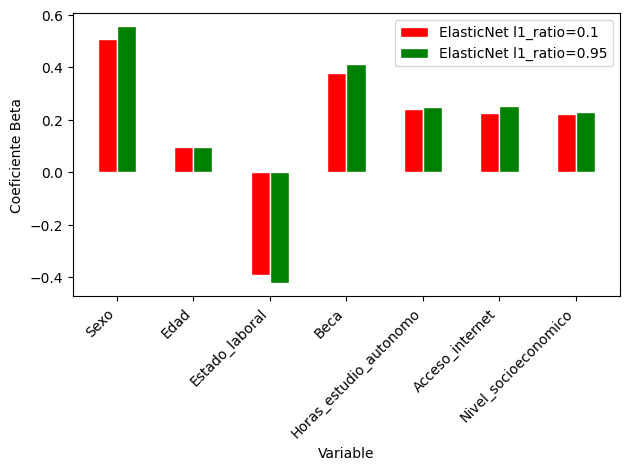

l1_ratio seleccionado automáticamente: 0.1


In [ ]:
# EJERCICIO ELASTIC NET
# Configurar semilla para reproducibilidad
np.random.seed(3)

# Definir X y y del dataset datos_estudiantiles
# Variables predictoras
X = datos_estudiantiles.drop(columns="Promedio").values
# Variable respuesta
y = datos_estudiantiles["Promedio"].values

# Ajustar ElasticNetCV para l1_ratio=0.1 (más ridge)
e_net = ElasticNetCV(cv=10, l1_ratio=0.1, random_state=3)
e_net.fit(X, y)

print("Intercepto modelo e_net:", e_net.intercept_)
print("Coeficientes modelo e_net:", e_net.coef_)

# Ajustar ElasticNetCV para l1_ratio=0.95 (más lasso)
e_net_b = ElasticNetCV(cv=10, l1_ratio=0.95, random_state=3)
e_net_b.fit(X, y)

print("Intercepto modelo e_net_b:", e_net_b.intercept_)
print("Coeficientes modelo e_net_b:", e_net_b.coef_)

# Visualización comparación coeficientes
barWidth = 0.25
r1 = np.arange(len(e_net.coef_))
r2 = r1 + barWidth

plt.bar(r1, e_net.coef_, color="red", width=barWidth, edgecolor="white", label="ElasticNet l1_ratio=0.1")
plt.bar(r2, e_net_b.coef_, color="green", width=barWidth, edgecolor="white", label="ElasticNet l1_ratio=0.95")

# Etiquetas de variables
variables = datos_estudiantiles.drop(columns="Promedio").columns.tolist()
plt.xticks(r1 + barWidth/2, variables, rotation=45, ha='right')

plt.xlabel("Variable")
plt.ylabel("Coeficiente Beta")
plt.legend()
plt.tight_layout()
plt.show()

# Ajustar ElasticNetCV con búsqueda automática sobre l1_ratio=[0.1, 0.95]
e_net_c = ElasticNetCV(cv=10, l1_ratio=[0.1, 0.95], random_state=3)
e_net_c.fit(X, y)

print("l1_ratio seleccionado automáticamente:", e_net_c.l1_ratio_)

Interpretando el gráfico y coeficientes:

* Variables como "Sexo" y "Beca" tienen coeficientes positivos relativamente altos, sugiriendo que influyen positivamente al promedio.
* "Estado_laboral" tiene coeficiente negativo, indicando que trabajar se asocia con menor promedio, probablemente por menos tiempo para estudio.
*   Variables con coeficientes cercanos entre ambos modelos indican efectos consistentes.
*   La selección automática de l1_ratio favorece la regularización que penaliza menos la complejidad del modelo con muchas variables (más Ridge que Lasso).

Métricas del modelo

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# Preparar datos
# -------------------------------
X = datos_estudiantiles.drop(columns=["Promedio"])
y = datos_estudiantiles["Promedio"]

# Identificar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Pipelines para preprocesamiento
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = OneHotEncoder(drop="first", handle_unknown="ignore")

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

# -------------------------------
# División en entrenamiento y prueba
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Preprocesar datos
X_train_p = full_pipeline.fit_transform(X_train)
X_test_p = full_pipeline.transform(X_test)

# -------------------------------
# Entrenar ElasticNet con CV
# -------------------------------
alphas = np.logspace(-3, 2, 50)   # rango de alphas
l1_ratios = [0.1, 0.5, 0.9]       # mezcla L1/L2

enet_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5,
                       max_iter=20000, random_state=42)
enet_cv.fit(X_train_p, y_train)

print(f"Mejor alpha ElasticNetCV: {enet_cv.alpha_}")
print(f"Mejor l1_ratio ElasticNetCV: {enet_cv.l1_ratio_}")

# -------------------------------
# Evaluación en test
# -------------------------------
y_pred = enet_cv.predict(X_test_p)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nEvaluación modelo ElasticNetCV en conjunto test:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# -------------------------------
# Coeficientes y variables
# -------------------------------
variables = full_pipeline.get_feature_names_out()
coeficientes = enet_cv.coef_

# Crear DataFrame ordenado por magnitud
df_coef = pd.DataFrame({
    "Variable": variables,
    "Coeficiente": coeficientes,
    "Importancia Relativa %": 100 * np.abs(coeficientes) / np.sum(np.abs(coeficientes))
}).sort_values(by="Importancia Relativa %", ascending=False)

print("\nCoeficientes del modelo:")
print(df_coef.head(15))  # mostrar las 15 más relevantes


Mejor alpha ElasticNetCV: 0.08685113737513529
Mejor l1_ratio ElasticNetCV: 0.1

Evaluación modelo ElasticNetCV en conjunto test:
RMSE: 1.1461
MAE: 0.8107
R2: 0.1728

Coeficientes del modelo:
                      Variable  Coeficiente  Importancia Relativa %
0                    num__Sexo     0.252882               18.306872
3                    num__Beca     0.216267               15.656179
4  num__Horas_estudio_autonomo     0.200641               14.524971
1                    num__Edad     0.198271               14.353415
2          num__Estado_laboral    -0.189707               13.733415
5         num__Acceso_internet     0.166212               12.032542
6    num__Nivel_socioeconomico     0.157372               11.392606


Análisis de salida.-
1. Hiperparámetros óptimos

*   Alpha (0.0868) → nivel de regularización global. Un valor pequeño indica que el modelo apenas penaliza los coeficientes, lo cual es coherente si los predictores tienen información relevante.
*   l1_ratio (0.1) → ElasticNet está mucho más cerca de Ridge (L2) que de Lasso (L1).
Esto significa que el modelo prefiere suavizar los coeficientes sin anularlos totalmente, lo que suele pasar cuando casi todas las variables tienen algo de poder explicativo.

2. Métricas de evaluación
*   RMSE = 1.1461
*   MAE = 0.8107. El error promedio absoluto es ~0.81 puntos, lo cual no es malo si las notas están en una escala de 0–10, pero tampoco es muy alto en poder predictivo.
*   R² = 0.1728. El modelo explica aproximadamente el 17 % de la variabilidad del rendimiento académico.

ElasticNet está captando cierta señal, pero no es un modelo fuerte en predicción.






**Modelos de mezclas Bayesianas**


Ajustando modelo GMM clásico con K=3...
Centroides GMM:
[[-5.93346519e-01 -3.20740826e-01  9.80196059e-01  2.67261242e-01
  -6.34185547e-01  1.13761376e-01 -4.28393043e-01 -3.71124564e+00]
 [-6.32617465e-04 -9.11613929e-02 -1.44116417e-01  1.06904497e+00
   2.65120700e-02 -3.57061252e-02 -1.34012422e-03  2.57894397e-01]
 [ 1.93253240e-02  8.91950314e-02  9.39428411e-02 -9.35414347e-01
  -2.91915097e-03  2.73603309e-02  1.47187483e-02 -1.06172812e-01]]
Pesos GMM:
[0.01666667 0.45666667 0.52666667]

Ajustando modelo Bayesian GMM con K máximo = 10...
Número efectivo de clusters (pesos > 0.05): 7
Centroides Bayesian GMM:
[[ 0.9761846   0.08969807 -0.98929009  0.36850753 -0.25973056 -0.93596897
   0.13353302  0.33478775]
 [-0.9752718   0.15887685 -0.12966982  1.04958346 -0.16261359  0.20829575
   0.10236552  0.41748787]
 [ 0.75500975 -0.89756917  0.2350608   0.30068211 -0.04324912  0.68758077
  -0.8720451  -0.5934996 ]
 [-0.868634    0.26041147  0.85712688  0.43443181  1.50743387  0.053901

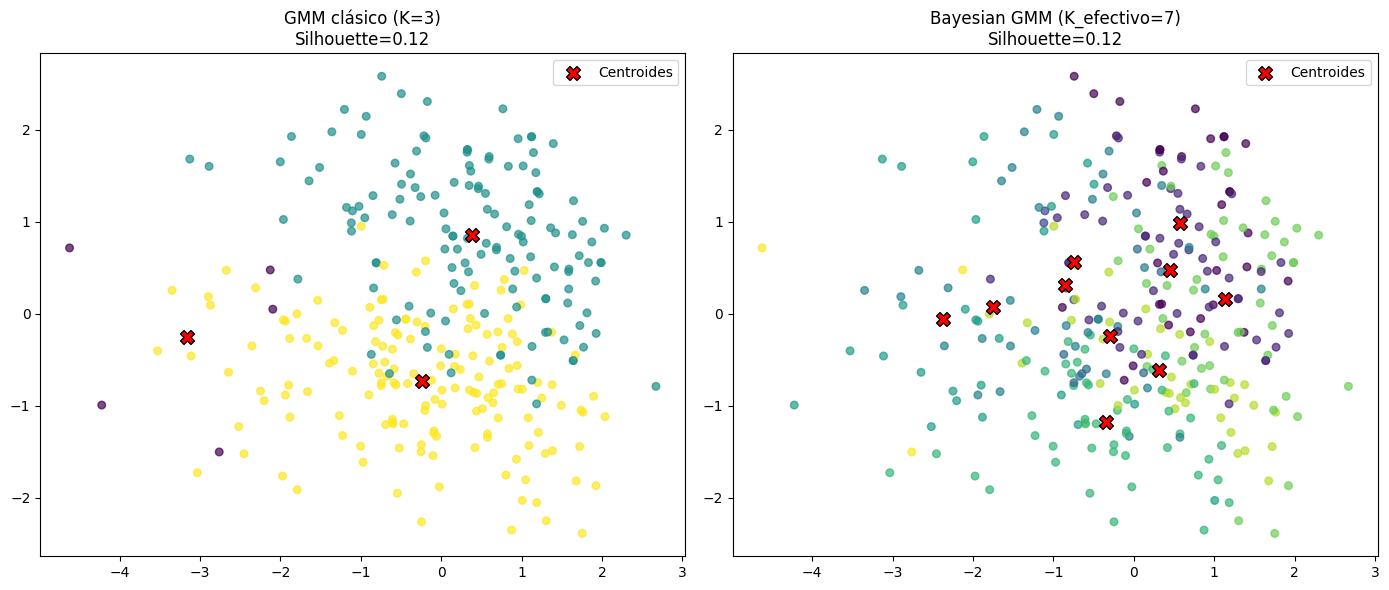

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ----------------------------------------------------------------------
# 1. Cargar datos (ajusta si tu DataFrame ya está en memoria)
# ----------------------------------------------------------------------
# Supongamos que tu DataFrame se llama datos_estudiantiles
# y quieres usar solo las variables numéricas para clustering
X = datos_estudiantiles.select_dtypes(include=[np.number]).values

# Escalado para mejorar el ajuste del modelo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------------------
# 2. Modelo GMM clásico
# ----------------------------------------------------------------------
print("\nAjustando modelo GMM clásico con K=3...")
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)

print("Centroides GMM:")
print(gmm.means_)
print("Pesos GMM:")
print(gmm.weights_)

# ----------------------------------------------------------------------
# 3. Modelo Bayesian Gaussian Mixture
# ----------------------------------------------------------------------
print("\nAjustando modelo Bayesian GMM con K máximo = 10...")
bgmm = BayesianGaussianMixture(
    n_components=10,
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=0.5,  # se ajusta aquí
    random_state=42
)

bgmm.fit(X_scaled)
labels_bgmm = bgmm.predict(X_scaled)

active_clusters = np.sum(bgmm.weights_ > 0.05)
print(f"Número efectivo de clusters (pesos > 0.05): {active_clusters}")
print("Centroides Bayesian GMM:")
print(bgmm.means_)
print("Pesos Bayesian GMM:")
print(bgmm.weights_)

# ----------------------------------------------------------------------
# 4. Evaluación con índice de Silhouette
# ----------------------------------------------------------------------
print("\nCalculando índice de Silhouette...")
if len(np.unique(labels_gmm)) > 1:
    sil_gmm = silhouette_score(X_scaled, labels_gmm)
else:
    sil_gmm = -1

if len(np.unique(labels_bgmm)) > 1:
    sil_bgmm = silhouette_score(X_scaled, labels_bgmm)
else:
    sil_bgmm = -1

print(f"Silhouette GMM clásico: {sil_gmm:.4f}")
print(f"Silhouette Bayesian GMM: {sil_bgmm:.4f}")

# ----------------------------------------------------------------------
# 5. Visualización en 2D con PCA
# ----------------------------------------------------------------------
print("\nVisualizando resultados...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GMM clásico ---
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='viridis', s=30, alpha=0.7)
centers_gmm = pca.transform(gmm.means_)
axes[0].scatter(centers_gmm[:, 0], centers_gmm[:, 1], marker='X', s=100,
                c='red', edgecolors='black', label='Centroides')
axes[0].set_title(f"GMM clásico (K=3)\nSilhouette={sil_gmm:.2f}")
axes[0].legend()

# --- Bayesian GMM ---
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_bgmm, cmap='viridis', s=30, alpha=0.7)
centers_bgmm = pca.transform(bgmm.means_)
axes[1].scatter(centers_bgmm[:, 0], centers_bgmm[:, 1], marker='X', s=100,
                c='red', edgecolors='black', label='Centroides')
axes[1].set_title(f"Bayesian GMM (K_efectivo={active_clusters})\nSilhouette={sil_bgmm:.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()


### **Resultados**

# **4. Conclusiones**

De la regresión:

*   Factores académicos y sociales influyen más que los estrictamente personales. La beca, estudio autónomo, internet y nivel socioeconómico tienen gran peso.
*   El trabajo resta rendimiento académico.
Lo cual concuerda con literatura previa.

*   El modelo no predice con gran exactitud (R² bajo), pero sí identifica qué factores diferencian el rendimiento








